# Parameterized Analysis of Multiple MGnify Studies

![MGnify](../assets/figs/mgnify_banner.png)

This notebook runs a complete bacterial diversity analysis using a configuration dictionary to control all parameters.

**Key features:**
1. Single configuration dictionary for all analysis parameters
2. Linear execution flow without code repetition
3. Conditional plot generation based on flags
4. Automated output management

**Pipeline with options**
1. Counts
2. Filter on minimum reads per sample
3. Filtering based on prok vs euk
4. Normalization `TSS`, `Rarefaction`
5. Compositional Transform `CLR`

## Setup and Imports

In [ ]:
from pathlib import Path

# Dataframes and display
import pandas as pd
import numpy as np
from tqdm import tqdm

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# Warning verbosity
import warnings 
warnings.filterwarnings(action="ignore")

from mgnify_methods.utils.logging import get_logger

logger = get_logger('nb_multiple_studies', level="INFO")
logger.info("Hello from mgnify_methods")
%matplotlib inline 

INFO | nb_multiple_studies | Hello from mgnify_methods


In [2]:
# Import all required functions
from momics.taxonomy import (
    fill_taxonomy_placeholders,
    rarefy_table,
)

from mgnify_methods.taxonomy import (
    aggregate_by_taxonomic_level,
    fill_lower_taxa,
    pivot_taxonomic_data,
    remove_singletons_per_sample,
)

from mgnify_methods.utils.plot import (
    plot_feature_reads_hist,
    plot_taxonomic_overlap,
    violin_plot_taxon,
)

from mgnify_methods.metacomp.rarefaction import (
    rarefaction_curve,
    calc_rarefaction_curves,
    calculate_min_rarefaction_depth,
)
from mgnify_methods.metacomp.transforms import (
    apply_preprocessing_method,
    apply_transform_method,
)
from mgnify_methods.metacomp.diversity import alpha_diversity_analysis
from mgnify_methods.utils.io import (
    load_taxonomy_summary,
    filter_tax_summary,
    assert_taxonomy_integrity,
    process_analysis_metadata,
    filter_analysis_meta,
    process_samples_metadata,
    enhance_samples_metadata,
    filter_number_reads,
)

from mgnify_methods import TaxonomyTable, AbundanceTable

# Beta diversity
from skbio.diversity import beta_diversity
from skbio.stats.ordination import pcoa

## Configuration Dictionary

All analysis parameters are defined here. Modify this dictionary to control the entire analysis flow.

In [3]:
# ============================================================================
# ANALYSIS CONFIGURATION
# ============================================================================

CONFIG = {
    # === Data Sources ===
    'datasets': {
        'Sola': ['MGYS00006680', 'mgnify_data/SRP237882_taxonomy_abundances_SSU_v5.0.tsv'],
        'OSD2018': ['MGYS00006608', 'mgnify_data/ERP124424_taxonomy_abundances_SSU_v5.0.tsv'],
    },
    
    # === Output Configuration ===
    'output': {
        'use_timestamp': True,  # Create timestamped output folder
        'cache_dir': 'analysis_cache',  # Cache directory for downloaded data
    },
    
    # === Filtering Parameters ===
    'filtering': {
        'min_reads_cutoff': 25000,  # Minimum reads per sample
        # 'prevalence_percent': 0.005,  # Prevalence cutoff (0.5%)
    },
    
    # === Taxonomic Settings ===
    'taxonomy': {
        'ranks': ['superkingdom', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species'],
        'analysis_level': 'phylum', #, 'class', 'order', 'family', 'genus',  # Levels for detailed analysis
        'filter_to_bacteria': True,  # Focus only on bacterial taxa
    },
    
    # === Sample Selection ===
    'samples': {
        'sample_type': 'prok',  # 'prok' or 'euk'
    },
    
    # === Preprocess Settings ===
    'preprocess': {
        'method_params': {
            'rarefaction': {
                'depth': None,  # None = auto-calculate minimum depth
                'n_points': 50,  # Number of points for rarefaction curves
            },
        },
    },
    
    # === Diversity Analysis ===
    'diversity': {
        'alpha': {
            'enabled': True,
            'dropna': False,  # Drop NA values during aggregation
            'remove_singletons': False,  # Remove taxa appearing only once per sample
            'rarefy': False,  # Rarefy samples to minimum depth before alpha diversity analysis
        },
    },
    
    # === Feature Analysis ===
    'feature': 'study_tag',  # features to analyze
    
    # === Plot Flags ===
    'plots': {
        'reads_histogram': True,
        'taxonomic_overlap_venn': True,
        'rarefaction_curves': True,
        'rarefaction_mean_std': True,
        'rarefaction_mean_ci': True,
        'rarefaction_individual': False,  # Can be very cluttered
        'alpha_diversity': True,
        'beta_diversity_pcoa': False,
        'taxa_prevalence_violin': True,
        'feature_rarefaction': True,  # Rarefaction curves per feature value
        'save_figures': False,  # Save figures to output folder
        'dpi': 300,  # DPI for saved figures
    },
}

print("Configuration loaded successfully!")
print(f"\nDatasets: {list(CONFIG['datasets'].keys())}")
print(f"Taxonomic level for analysis: {CONFIG['taxonomy']['analysis_level']}")
print(f"Feature to analyze: {CONFIG['feature']}")

Configuration loaded successfully!

Datasets: ['Sola', 'OSD2018']
Taxonomic level for analysis: phylum
Feature to analyze: study_tag


## Initialize Output Directories

In [4]:
# Extract configuration
TAXONOMY_RANKS = CONFIG['taxonomy']['ranks']
ds = CONFIG['datasets']

# Create output directories
if CONFIG['output']['use_timestamp']:
    stamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M')
    OUT_FOLDER = Path('analysis_' + stamp).resolve()
else:
    OUT_FOLDER = Path('analysis_latest').resolve()

ANALYSIS_CACHE = Path(CONFIG['output']['cache_dir']).resolve()

# add OUT_FOLDER to config for later use
CONFIG['output']['out_folder'] = str(OUT_FOLDER)
CONFIG['input'] = {'cache_dir': str(ANALYSIS_CACHE)}

for folder in [OUT_FOLDER, ANALYSIS_CACHE]:
    folder.mkdir(parents=True, exist_ok=True)
    print(f"Directory ready: {folder}")

# Save configuration to output folder
import json
config_path = OUT_FOLDER / 'analysis_config.json'
with open(config_path, 'w') as f:
    json.dump(CONFIG, f, indent=2)
print(f"\nConfiguration saved to: {config_path}")

Directory ready: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260210_1432
Directory ready: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_cache

Configuration saved to: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260210_1432/analysis_config.json


## Load Metadata from MGnify

In [5]:
# Fetch analysis metadata
analysis_meta = process_analysis_metadata(ANALYSIS_CACHE, ds)
print(f"Loaded {len(analysis_meta)} analyses")

# Fetch and enhance sample metadata
samples_meta = process_samples_metadata(ANALYSIS_CACHE, ds)
samples_meta = enhance_samples_metadata(samples_meta)
print(f"Loaded {len(samples_meta)} samples")

INFO | mgnify_methods.utils.io | Analysis Sola has 283 samples.
INFO | mgnify_methods.utils.io | Analysis OSD2018 has 62 samples.
INFO | mgnify_methods.utils.io | Analysis Sola has 283 samples.
INFO | mgnify_methods.utils.io | Analysis OSD2018 has 62 samples.
INFO | mgnify_methods.utils.io | Dropped 2 rows with invalid or missing collection_date (2 actually removed).
INFO | mgnify_methods.utils.io | Filtered samples to prokaryotes only: 343 -> 202


Loaded 345 analyses
Loaded 202 samples


## Filter Samples by Read Count


=== Reads Distribution (Unfiltered) ===
Samples not matched to study_tag metadata: 143


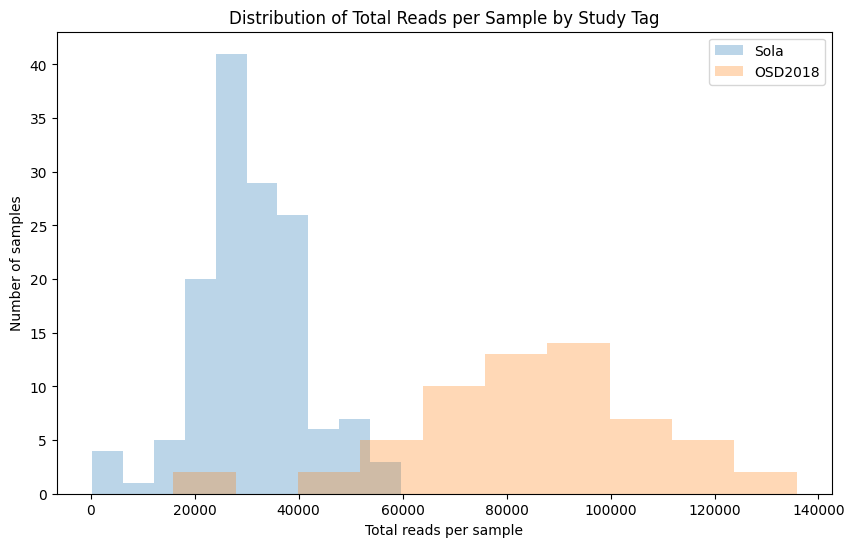

INFO | mgnify_methods.utils.io | Dropping 37 samples with less than 25000 reads: ['SRR10717050', 'SRR10717046', 'SRR10717023', 'SRR10717010', 'SRR10717002', 'SRR10716996', 'SRR10716995', 'SRR10716991', 'SRR10716988', 'SRR10716977', 'SRR10716972', 'SRR10716954', 'SRR10716950', 'SRR10716990', 'SRR10716985', 'SRR10716971', 'SRR10716970', 'SRR10716910', 'SRR10717005', 'SRR10716989', 'SRR10716983', 'SRR10716979', 'SRR10716974', 'SRR10716969', 'SRR10716966', 'SRR10716963', 'SRR10716962', 'SRR10716948', 'SRR10716938', 'SRR10716933', 'SRR10716928', 'SRR10716916', 'SRR10716915', 'SRR10716902', 'SRR10716900', 'ERR4674181', 'ERR4674146']



Filtering samples with < 25000 reads: 37 samples to remove
Remaining analyses after filtering: 308

=== Reads Distribution (Filtered) ===
Samples not matched to study_tag metadata: 143


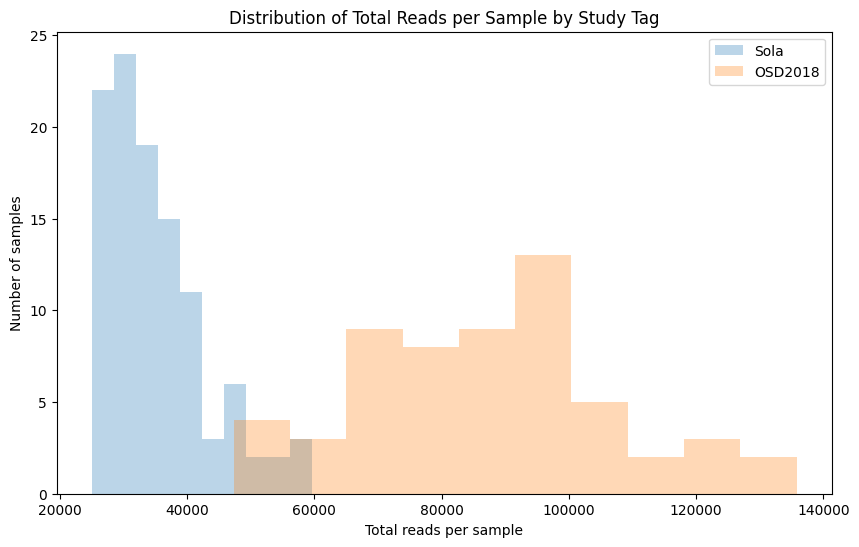

In [6]:
# Plot reads distribution before filtering
if CONFIG['plots']['reads_histogram']:
    print("\n=== Reads Distribution (Unfiltered) ===")
    total_dict = plot_feature_reads_hist(
        analysis_meta=analysis_meta,
        samples_meta=samples_meta,
        feature=CONFIG['feature'],
        name=f'{CONFIG["feature"]}_reads_unfiltered.png' if CONFIG['plots']['save_figures'] else None,
        out_dir=OUT_FOLDER if CONFIG['plots']['save_figures'] else None,
        use_robust_save=False,
    )

# Apply filtering
cutoff = CONFIG['filtering']['min_reads_cutoff']
to_drop = filter_number_reads(total_dict, cutoff)
print(f"\nFiltering samples with < {cutoff} reads: {len(to_drop)} samples to remove")

for sample in to_drop:
    analysis_meta = analysis_meta[analysis_meta.index != sample]

print(f"Remaining analyses after filtering: {len(analysis_meta)}")

# Plot reads distribution after filtering
if CONFIG['plots']['reads_histogram']:
    print("\n=== Reads Distribution (Filtered) ===")
    total_dict = plot_feature_reads_hist(
        analysis_meta=analysis_meta,
        samples_meta=samples_meta,
        feature=CONFIG['feature'],
        name=f'{CONFIG["feature"]}_reads_unfiltered.png' if CONFIG['plots']['save_figures'] else None,
        out_dir=OUT_FOLDER if CONFIG['plots']['save_figures'] else None,
        use_robust_save=False,
    )

## Load and Merge Taxonomy Data

In [7]:
# Get data folder path
root_folder = Path.cwd().parent
data_folder = root_folder / 'data'

df_tax_summary = load_taxonomy_summary(ds, data_folder)

INFO | mgnify_methods.utils.io | Loaded Sola: (3484, 283)
INFO | mgnify_methods.utils.io | Loaded OSD2018: (1981, 62)
INFO | mgnify_methods.utils.io | 
Merged taxonomy table: (4221, 345)


## Synchronize Metadata and Taxonomy Tables

In [8]:
# Remove samples not in metadata
analysis_meta = filter_analysis_meta(analysis_meta, samples_meta)
df_tax_summary = filter_tax_summary(df_tax_summary, analysis_meta)

# check data integrity
assert_taxonomy_integrity(df_tax_summary, analysis_meta)

INFO | mgnify_methods.utils.io | Dropped 143 samples from analysis_meta: 308 -> 165
INFO | mgnify_methods.utils.io | 
Taxonomy samples before filtering: 345
INFO | mgnify_methods.utils.io | 
Taxonomy samples before filtering: 345
INFO | mgnify_methods.utils.io | Taxonomy samples after filtering: 165
INFO | mgnify_methods.utils.io | 
Removing 1965 taxa with all zero counts
INFO | mgnify_methods.utils.io | 
✓ Data tables synchronized successfully


## Convert to TaxonomyTable Format

In [9]:
# Convert abundance table to taxonomy table
abundance_table = AbundanceTable(df_tax_summary.reset_index(), source='tax_mgnify_raw')
ncbi_flag, taxonomy_table = abundance_table.to_taxonomy_table()

taxonomy_table.df.sort_values(by=['source material ID', 'abundance'], inplace=True)

# Fill missing taxonomic information
taxonomy_table.df = fill_lower_taxa(taxonomy_table.df, TAXONOMY_RANKS)
taxonomy_table.df = fill_taxonomy_placeholders(taxonomy_table.df, TAXONOMY_RANKS)

if not taxonomy_table.df.index.name == 'source material ID':
    taxonomy_table.df = taxonomy_table.df.set_index('source material ID')

print(f"\nTaxonomy table ready: {taxonomy_table.df.shape}")

INFO | mgnify_methods.tables.tables | Converting source: tax_mgnify_raw
WARNING | mgnify_methods.tables.tables | DataFrame is abundance without ncbi_tax_id data.
INFO | mgnify_methods.tables.tables | self.source before conversion to Taxonomy table: tax_mgnify_raw
INFO | mgnify_methods.tables.tables | Converting source: tax_processed
INFO | mgnify_methods.tables.sources.converters | Abundance dtype after conversion: uint16
INFO | mgnify_methods.tables.tables | Validating source: tax_processed



Taxonomy table ready: (46870, 9)


## Filter to Target Sample Type
- either `prok` or `euk`

In [10]:
# Get sample list for selected sample type
sample_type = CONFIG['samples']['sample_type']
sample_list = samples_meta[samples_meta['sample_type'] == sample_type]['id'].tolist()
data_list = analysis_meta[analysis_meta['relationships.sample.data.id'].isin(sample_list)].index.tolist()

# Filter taxonomy table
taxonomy_table.df_filt = taxonomy_table.df[taxonomy_table.df.index.isin(data_list)]

print(f"Filtered to {sample_type} samples: {len(data_list)} samples")
print(f"Filtered taxonomy table: {taxonomy_table.df_filt.shape}")

Filtered to prok samples: 165 samples
Filtered taxonomy table: (46870, 9)


## Taxonomic Overlap Analysis

In [11]:
# if CONFIG['plots']['taxonomic_overlap_venn']:
#     logger.info("\n=== Taxonomic Overlap Analysis ===")
#     plot_taxonomic_overlap(taxonomy_table, analysis_meta, CONFIG)

## Preprocessing
- aggregate by taxonomic level (this is done on the Taxonomy table)
- then convert to abundance table
- then prevalence cutoff
- then preprocessing normlization `rarefaction`, `tss`, `tss_sqrt`

**This is supposed to be rewritten using only the OOP TaxonomyTable and AbendanceTable**

In [12]:
tax_level = CONFIG['taxonomy']['analysis_level']
table = aggregate_by_taxonomic_level(
    taxonomy_table.df_filt, level=tax_level, dropna=CONFIG['diversity']['alpha']['dropna']
)

In [13]:
abundance_table = pivot_taxonomic_data(table)
type(abundance_table)

pandas.core.frame.DataFrame

## Apha diversity analysis
- Needs to be on counts

**Three cases**
1. No additional preprocessing
2. Only removing singletons
3. Only rarefaction

Both removing singletons and rarefaction is not recommended

In [14]:
tax_level = CONFIG['taxonomy']['analysis_level']

### Case 1, no preprocessing

INFO | mgnify_methods.metacomp.diversity | 
=== Alpha Diversity Analysis ===
INFO | mgnify_methods.metacomp.diversity | Analyzing at phylum level...
INFO | mgnify_methods.metacomp.diversity | Data: 165 samples, 140 taxa
INFO | mgnify_methods.metacomp.diversity | Study distribution: {'Sola': 107, 'OSD2018': 58}
INFO | mgnify_methods.metacomp.diversity | 
Saved diversity results to: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260210_1432/alpha_diversity_phylum_no_processing.csv


Calculated diversity for 165 samples


shannon                                                  simpson  \
            count   mean    std    min    25%    50%    75%    max   count   
study_tag                                                                    
OSD2018      58.0  1.458  0.285  0.506  1.296  1.490  1.647  1.926    58.0   
Sola        107.0  1.347  0.165  0.900  1.238  1.379  1.476  1.681   107.0   

                                                           observed_otus  \
            mean    std    min    25%    50%    75%    max         count   
study_tag                                                                  
OSD2018    0.675  0.116  0.222  0.627  0.698  0.749  0.833          58.0   
Sola       0.617  0.068  0.393  0.573  0.625  0.672  0.742         107.0   

                                                          chao1          \
             mean     std   min    25%   50%   75%   max  count    mean   
study_tag                                                                 
OSD2018    38.759  13.334  11.0  30.25  37.5  48.0  71.0   58.0  46.717   
Sola       32.720   8.882  19.0  27.00  31.0  36.0  70.0  107.0  45.773   

                                                        
              std   min     25%     50%     75%    max  
study_tag                                               
OSD2018    17.577  11.0  34.850  46.071  55.469  114.5  
Sola       16.522  22.2  33.417  42.250  53.550  100.0

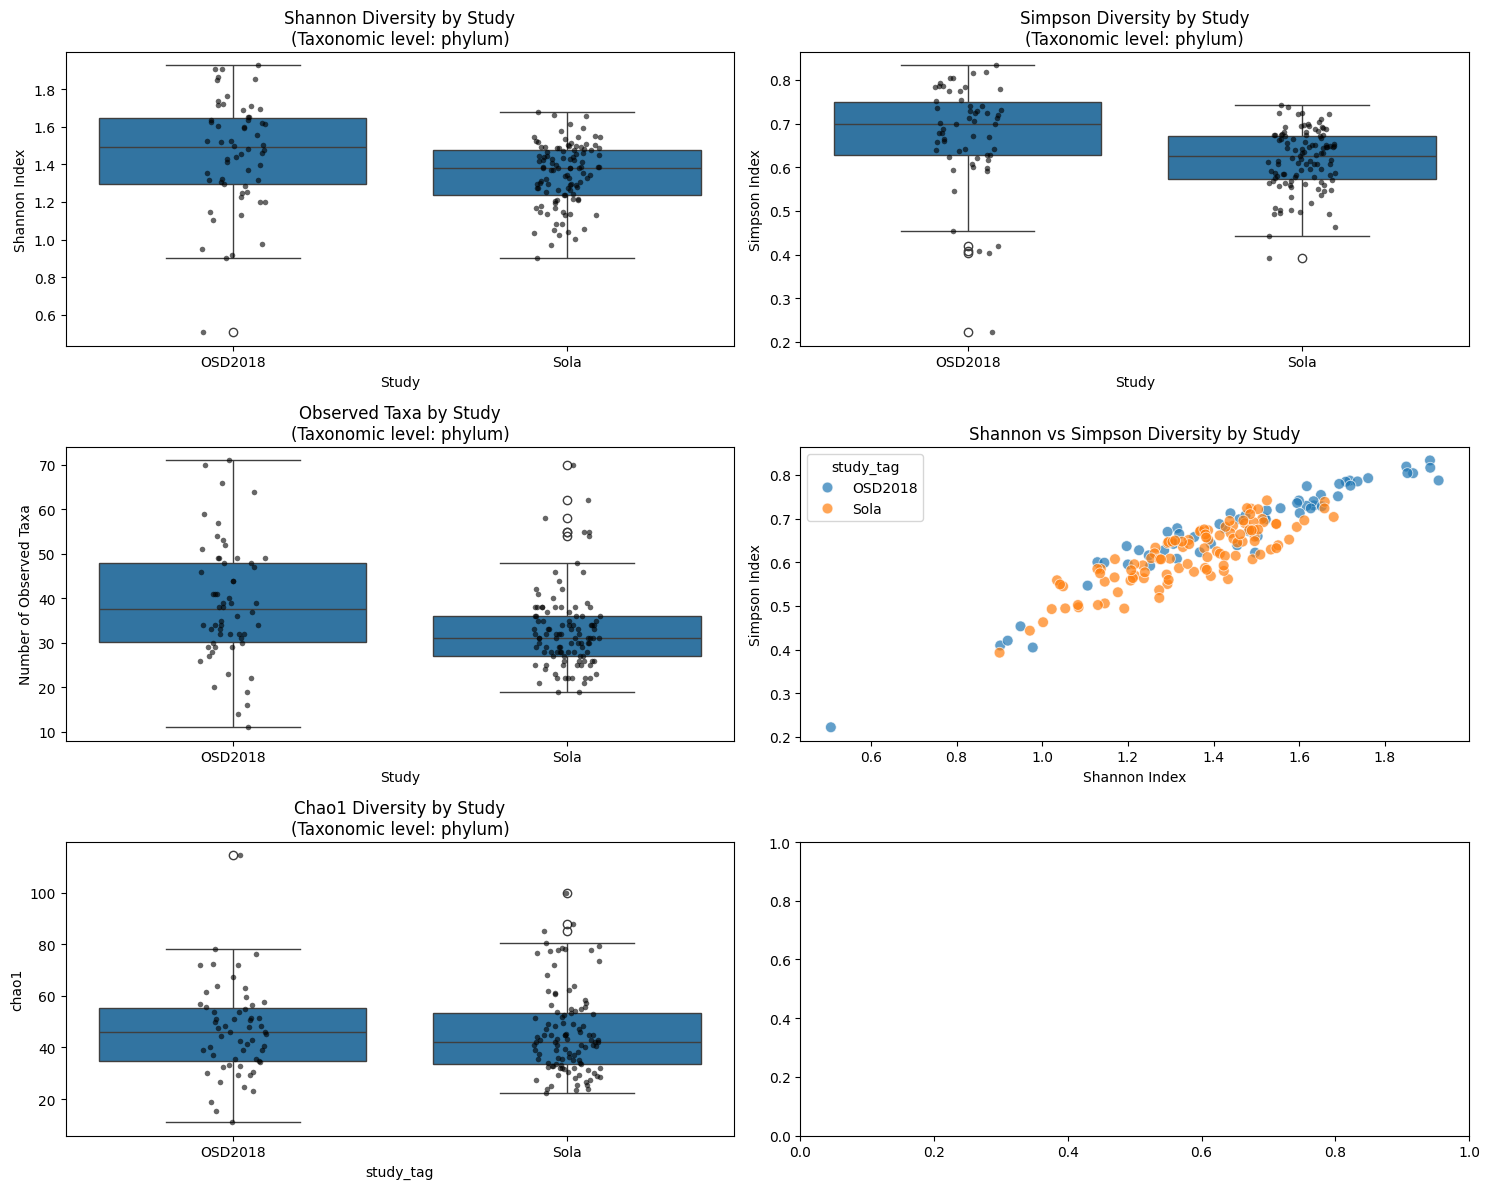

INFO | mgnify_methods.stats | 
INFO | mgnify_methods.stats | STATISTICAL COMPARISON OF ALPHA DIVERSITY BETWEEN STUDIES
INFO | mgnify_methods.stats | ============================================================
INFO | mgnify_methods.stats | 
SHANNON - Mann-Whitney U test
INFO | mgnify_methods.stats | 
SIMPSON - Mann-Whitney U test
INFO | mgnify_methods.stats | 
OBSERVED_OTUS - Mann-Whitney U test
INFO | mgnify_methods.stats | 
CHAO1 - Mann-Whitney U test


,Metric,median OSD2018,median Sola,Delta Median,Rank Biserial Correlation,CliffDelta,U-Statistic,P-Value,direction
0,shannon,1.489941,1.378675,0.111266,-0.312923,0.312923,4074.0,0.000925,OSD2018 > Sola
1,simpson,0.698329,0.624790,0.073539,-0.456655,0.456655,4520.0,0.000001,OSD2018 > Sola
2,observed_otus,37.500000,31.000000,6.500000,-0.321624,0.321624,4101.0,0.000656,OSD2018 > Sola
3,chao1,46.071429,42.250000,3.821429,-0.069771,0.069771,3319.5,0.460984,OSD2018 > Sola


In [15]:
CONFIG['output']['alpha_tag'] = 'no_processing'
summary_case1, df_case1, stats_case1 = alpha_diversity_analysis(abundance_table, analysis_meta, 
                                                                samples_meta, CONFIG)

### Case 2, remove singletons

INFO | nb_multiple_studies | Removed singletons per sample
INFO | mgnify_methods.metacomp.diversity | 
=== Alpha Diversity Analysis ===
INFO | mgnify_methods.metacomp.diversity | Analyzing at phylum level...
INFO | mgnify_methods.metacomp.diversity | Data: 165 samples, 106 taxa
INFO | mgnify_methods.metacomp.diversity | Study distribution: {'Sola': 107, 'OSD2018': 58}
INFO | mgnify_methods.metacomp.diversity | 
Saved diversity results to: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260210_1432/alpha_diversity_phylum_remove_singletons.csv


Removed 34 singleton features. Shape reduced from (140, 165) → (106, 165)
Calculated diversity for 165 samples


shannon                                                  simpson  \
            count   mean    std    min    25%    50%    75%    max   count   
study_tag                                                                    
OSD2018      58.0  1.456  0.285  0.506  1.291  1.488  1.645  1.923    58.0   
Sola        107.0  1.343  0.165  0.897  1.234  1.376  1.471  1.676   107.0   

                                                           observed_otus  \
            mean    std    min    25%    50%    75%    max         count   
study_tag                                                                  
OSD2018    0.675  0.116  0.222  0.627  0.698  0.748  0.833          58.0   
Sola       0.617  0.068  0.392  0.573  0.624  0.671  0.741         107.0   

                                                           chao1          \
             mean     std   min    25%   50%    75%   max  count    mean   
study_tag                                                                  
OSD2018    30.586  12.189  11.0  22.25  28.0  38.75  61.0   58.0  30.586   
Sola       22.645   6.464  13.0  19.00  22.0  25.50  54.0  107.0  22.645   

                                                   
              std   min    25%   50%    75%   max  
study_tag                                          
OSD2018    12.189  11.0  22.25  28.0  38.75  61.0  
Sola        6.464  13.0  19.00  22.0  25.50  54.0

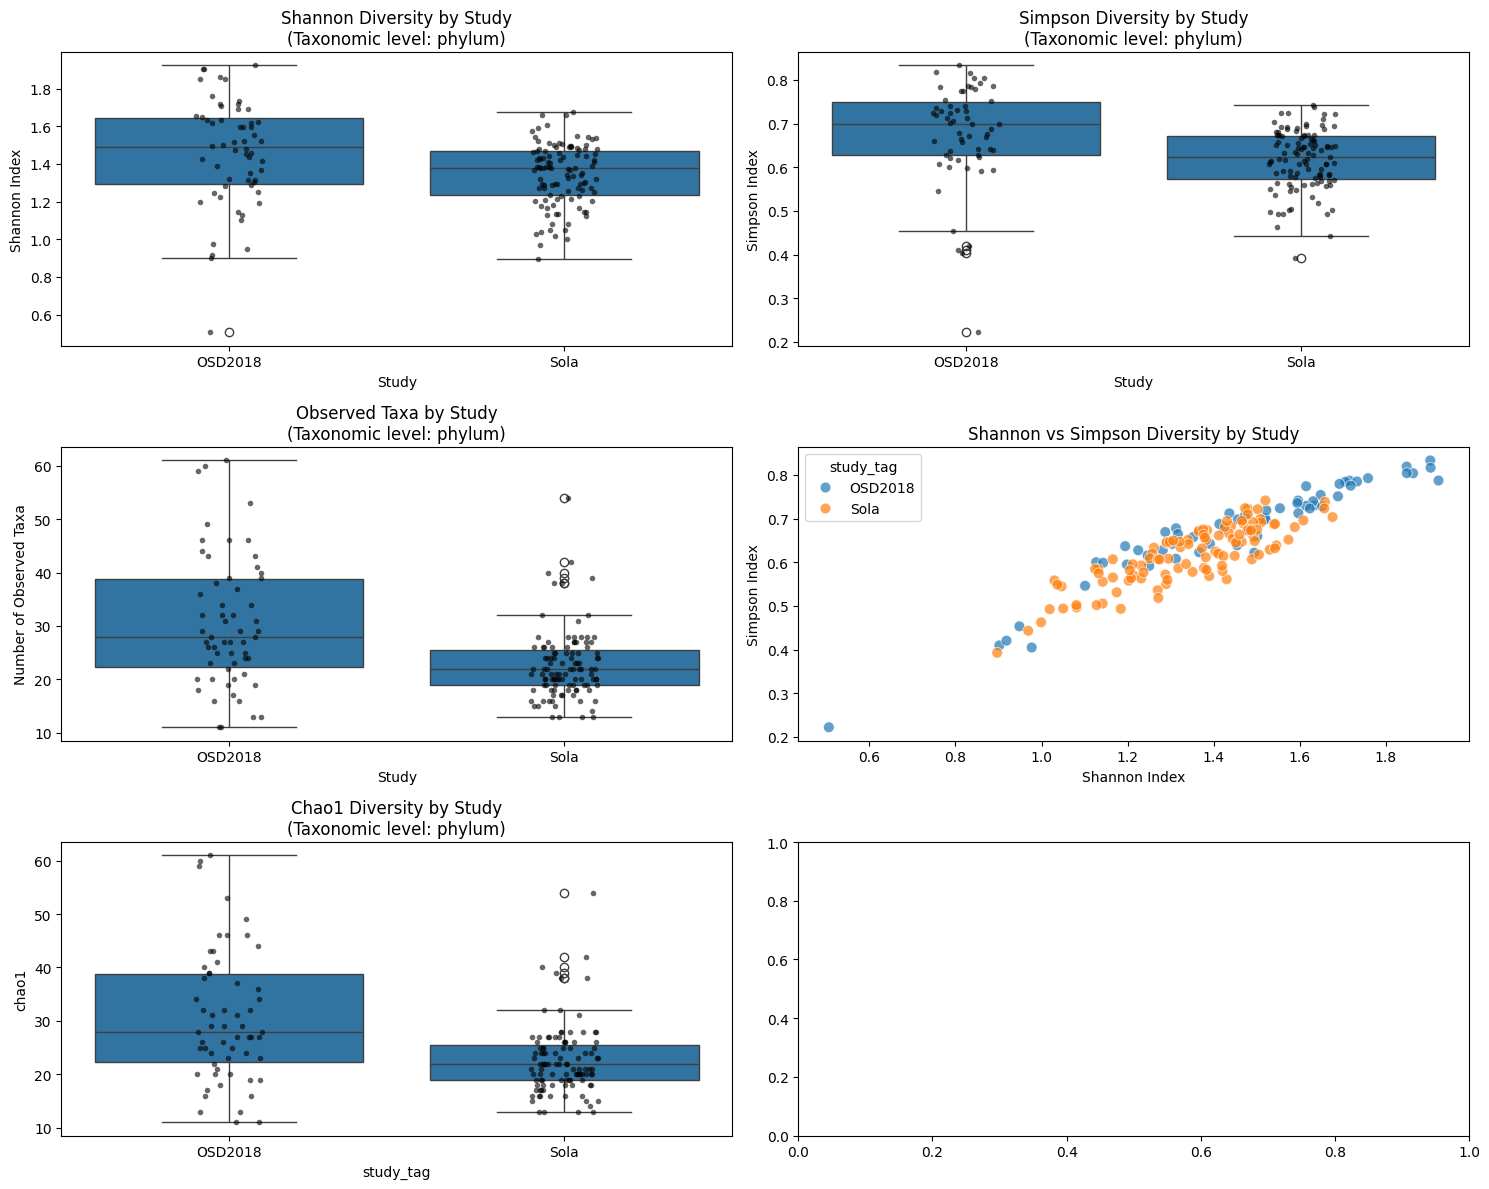

INFO | mgnify_methods.stats | 
INFO | mgnify_methods.stats | STATISTICAL COMPARISON OF ALPHA DIVERSITY BETWEEN STUDIES
INFO | mgnify_methods.stats | ============================================================
INFO | mgnify_methods.stats | 
SHANNON - Mann-Whitney U test
INFO | mgnify_methods.stats | 
SIMPSON - Mann-Whitney U test
INFO | mgnify_methods.stats | 
OBSERVED_OTUS - Mann-Whitney U test
INFO | mgnify_methods.stats | 
CHAO1 - Mann-Whitney U test


,Metric,median OSD2018,median Sola,Delta Median,Rank Biserial Correlation,CliffDelta,U-Statistic,P-Value,direction
0,shannon,1.487938,1.37575,0.112188,-0.316468,0.316468,4085.0,0.000809,OSD2018 > Sola
1,simpson,0.698154,0.62449,0.073664,-0.456655,0.456655,4520.0,0.000001,OSD2018 > Sola
2,observed_otus,28.000000,22.00000,6.000000,-0.431679,0.431679,4442.5,0.000005,OSD2018 > Sola
3,chao1,28.000000,22.00000,6.000000,-0.431679,0.431679,4442.5,0.000005,OSD2018 > Sola


In [16]:
abundance_table_alpha = abundance_table.copy()
abundance_table_alpha = remove_singletons_per_sample(abundance_table_alpha, skip_columns=0)
logger.info("Removed singletons per sample")

CONFIG['output']['alpha_tag'] = 'remove_singletons'
summary_case2, df_case2, stats_case2 = alpha_diversity_analysis(abundance_table_alpha, analysis_meta, samples_meta, CONFIG)

### Case 3, Rarefy

INFO | nb_multiple_studies | 
=== Calculating Minimum Rarefaction Depth ===
INFO | mgnify_methods.metacomp.rarefaction | Minimum rarefaction depth: 14591
INFO | nb_multiple_studies | Minimum rarefaction depth determined: 14591 reads
INFO | mgnify_methods.metacomp.diversity | 
=== Alpha Diversity Analysis ===
INFO | mgnify_methods.metacomp.diversity | Analyzing at phylum level...
INFO | mgnify_methods.metacomp.diversity | Data: 165 samples, 140 taxa
INFO | mgnify_methods.metacomp.diversity | Study distribution: {'Sola': 107, 'OSD2018': 58}


Minimum rarefaction depth: 14591
Minimum rarefaction depth: 14591


INFO | mgnify_methods.metacomp.diversity | 
Saved diversity results to: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260210_1432/alpha_diversity_phylum_rarefied.csv


Calculated diversity for 165 samples


shannon                                                  simpson  \
            count   mean    std    min    25%    50%    75%    max   count   
study_tag                                                                    
OSD2018      58.0  1.457  0.284  0.517  1.295  1.493  1.652  1.934    58.0   
Sola        107.0  1.346  0.165  0.907  1.236  1.375  1.474  1.680   107.0   

                                                           observed_otus  \
            mean    std    min    25%    50%    75%    max         count   
study_tag                                                                  
OSD2018    0.675  0.115  0.227  0.629  0.697  0.749  0.831          58.0   
Sola       0.617  0.068  0.396  0.573  0.627  0.669  0.741         107.0   

                                                          chao1          \
             mean     std   min    25%   50%   75%   max  count    mean   
study_tag                                                                 
OSD2018    30.603  11.309  11.0  23.25  29.0  37.0  59.0   58.0  39.186   
Sola       26.860   7.493  15.0  23.00  26.0  29.0  65.0  107.0  37.800   

                                                      
              std   min     25%   50%     75%    max  
study_tag                                             
OSD2018    14.808  11.0  28.357  39.0  47.425   72.6  
Sola       14.217  17.5  29.625  35.0  43.167  109.0

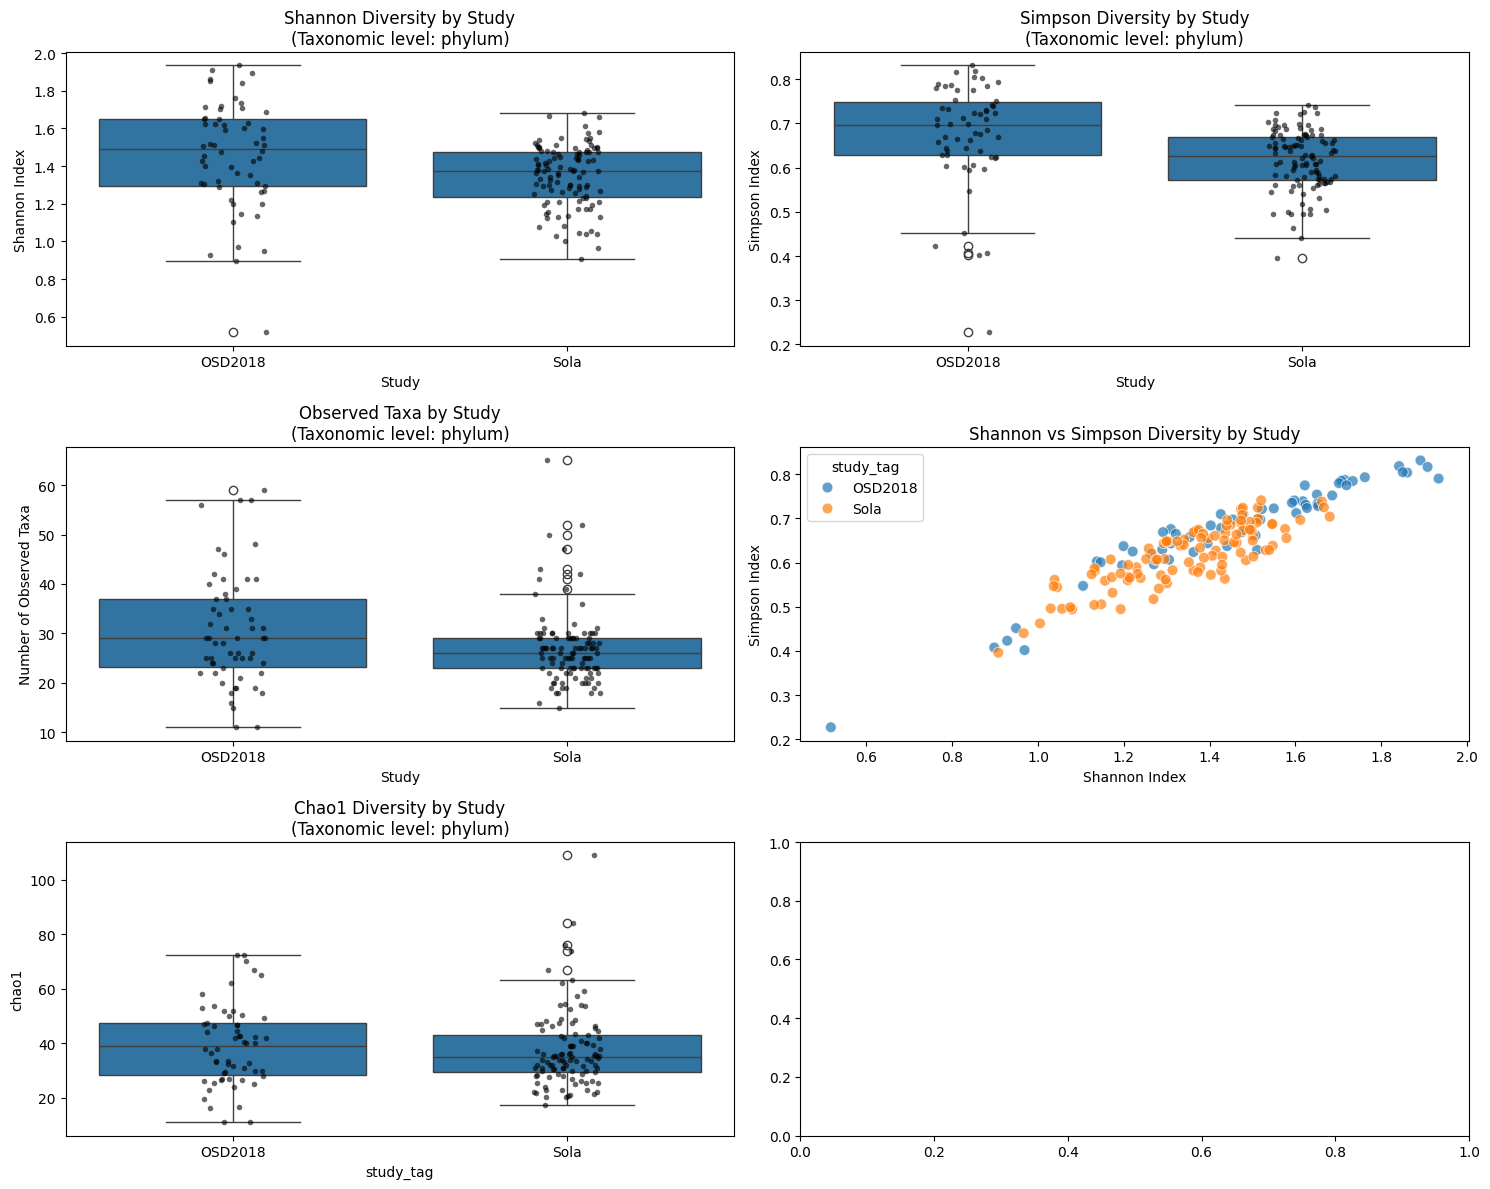

INFO | mgnify_methods.stats | 
INFO | mgnify_methods.stats | STATISTICAL COMPARISON OF ALPHA DIVERSITY BETWEEN STUDIES
INFO | mgnify_methods.stats | ============================================================
INFO | mgnify_methods.stats | 
SHANNON - Mann-Whitney U test
INFO | mgnify_methods.stats | 
SIMPSON - Mann-Whitney U test
INFO | mgnify_methods.stats | 
OBSERVED_OTUS - Mann-Whitney U test
INFO | mgnify_methods.stats | 
CHAO1 - Mann-Whitney U test


,Metric,median OSD2018,median Sola,Delta Median,Rank Biserial Correlation,CliffDelta,U-Statistic,P-Value,direction
0,shannon,1.492899,1.374524,0.118375,-0.313245,0.313245,4075.0,0.000914,OSD2018 > Sola
1,simpson,0.697186,0.626994,0.070192,-0.457622,0.457622,4523.0,0.000001,OSD2018 > Sola
2,observed_otus,29.000000,26.000000,3.000000,-0.193039,0.193039,3702.0,0.040747,OSD2018 > Sola
3,chao1,39.000000,35.000000,4.000000,-0.078311,0.078311,3346.0,0.407834,OSD2018 > Sola


In [17]:
abundance_table_alpha = abundance_table.copy()

logger.info("\n=== Calculating Minimum Rarefaction Depth ===")
MIN_DEPTH = calculate_min_rarefaction_depth(abundance_table_alpha)
logger.info(f"Minimum rarefaction depth determined: {MIN_DEPTH} reads")

abundance_table_alpha = rarefy_table(abundance_table_alpha, depth=MIN_DEPTH)


CONFIG['output']['alpha_tag'] = 'rarefied'
summary_case3, df_case3, stats_case3 = alpha_diversity_analysis(abundance_table_alpha, 
                                                   analysis_meta, samples_meta,
                                                   CONFIG)

## Comparison between treatments
- construct table like this

| Pipeline     | Metric  | Δmedian | Effect size | p     | Direction |
| ------------ | ------- | ------- | ----------- | ----- | --------- |
| Raw counts   | Shannon | +0.11   | 0.28        | 0.001 | OSD>SOLA  |
| CLR filtered | Shannon | +0.08   | 0.21        | 0.02  | OSD>SOLA  |
| Rarefied     | Shannon | +0.10   | 0.26        | 0.003 | OSD>SOLA  |

- calculate delta medians and effect sizes


In [18]:
# summary_case1.head()

In [19]:
# df_case1.head()

In [20]:
# stats_case1.head()

### Combine per metric

In [21]:
df = pd.concat([stats_case1, stats_case2, stats_case3], axis=0)

shannon_stats = df[df['Metric'] == 'shannon']
shannon_stats.index = ['No Processing', 'Remove Singletons', 'Rarefied']
shannon_stats.head()


,Metric,median OSD2018,median Sola,Delta Median,Rank Biserial Correlation,CliffDelta,U-Statistic,P-Value,direction
No Processing,shannon,1.489941,1.378675,0.111266,-0.312923,0.312923,4074.0,0.000925,OSD2018 > Sola
Remove Singletons,shannon,1.487938,1.375750,0.112188,-0.316468,0.316468,4085.0,0.000809,OSD2018 > Sola
Rarefied,shannon,1.492899,1.374524,0.118375,-0.313245,0.313245,4075.0,0.000914,OSD2018 > Sola


In [22]:
simpson_stats = df[df['Metric'] == 'simpson']
simpson_stats.index = ['No Processing', 'Remove Singletons', 'Rarefied']
simpson_stats.head()

,Metric,median OSD2018,median Sola,Delta Median,Rank Biserial Correlation,CliffDelta,U-Statistic,P-Value,direction
No Processing,simpson,0.698329,0.624790,0.073539,-0.456655,0.456655,4520.0,0.000001,OSD2018 > Sola
Remove Singletons,simpson,0.698154,0.624490,0.073664,-0.456655,0.456655,4520.0,0.000001,OSD2018 > Sola
Rarefied,simpson,0.697186,0.626994,0.070192,-0.457622,0.457622,4523.0,0.000001,OSD2018 > Sola


In [23]:
otus_stats = df[df['Metric'] == 'observed_otus']
otus_stats.index = ['No Processing', 'Remove Singletons', 'Rarefied']
otus_stats.head()

,Metric,median OSD2018,median Sola,Delta Median,Rank Biserial Correlation,CliffDelta,U-Statistic,P-Value,direction
No Processing,observed_otus,37.5,31.0,6.5,-0.321624,0.321624,4101.0,0.000656,OSD2018 > Sola
Remove Singletons,observed_otus,28.0,22.0,6.0,-0.431679,0.431679,4442.5,0.000005,OSD2018 > Sola
Rarefied,observed_otus,29.0,26.0,3.0,-0.193039,0.193039,3702.0,0.040747,OSD2018 > Sola


In [24]:
chao1_stats = df[df['Metric'] == 'chao1']
chao1_stats.index = ['No Processing', 'Remove Singletons', 'Rarefied']
chao1_stats.head()

,Metric,median OSD2018,median Sola,Delta Median,Rank Biserial Correlation,CliffDelta,U-Statistic,P-Value,direction
No Processing,chao1,46.071429,42.25,3.821429,-0.069771,0.069771,3319.5,0.460984,OSD2018 > Sola
Remove Singletons,chao1,28.000000,22.00,6.000000,-0.431679,0.431679,4442.5,0.000005,OSD2018 > Sola
Rarefied,chao1,39.000000,35.00,4.000000,-0.078311,0.078311,3346.0,0.407834,OSD2018 > Sola


## Summary

In [25]:
print("\n" + "="*60)
print("ANALYSIS SUMMARY")
print("="*60)
print(f"Output folder: {OUT_FOLDER}")
print(f"\nDatasets analyzed: {list(ds.keys())}")
print(f"Total samples: {len(analysis_meta)}")
print(f"Sample type: {sample_type}")
print(f"\nTaxonomic level: {CONFIG['taxonomy']['analysis_level']}")
print(f"\nFiltering:")
print(f"  Min reads: {CONFIG['filtering']['min_reads_cutoff']}")
print(f"\nPrimary grouping feature: {CONFIG['feature']}")
print("="*60)


ANALYSIS SUMMARY
Output folder: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260210_1432

Datasets analyzed: ['Sola', 'OSD2018']
Total samples: 165
Sample type: prok

Taxonomic level: phylum

Filtering:
  Min reads: 25000

Primary grouping feature: study_tag
